In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(x, **k): return x

SEED = 42
N_SCENARIOS = 100

In [ ]:
# Model constants
BASELINE_SETPOINT = 22.0
HVAC_SENSITIVITY  = 0.08
COMFORT_LOW  = 20.0
COMFORT_HIGH = 24.0
COMFORT_TOL  = 0.5
THERMAL_DECAY = 0.85
STORAGE_GAIN  = 0.8
DEFERRABLE_KW = 40.0
DEFERRABLE_DURATION = 4
DEFERRABLE_EARLIEST = 0
DEFERRABLE_LATEST   = 22
BASELINE_DEFER_HOUR = 12

def comfort_breach(sp):
    below = np.maximum(COMFORT_LOW - sp, 0)
    above = np.maximum(sp - COMFORT_HIGH, 0)
    return float(np.max(below + above))

def deferrable_profile(h):
    s = int(np.clip(np.round(h), DEFERRABLE_EARLIEST, DEFERRABLE_LATEST))
    p = np.zeros(24); p[s:s+DEFERRABLE_DURATION] = DEFERRABLE_KW
    return p

In [3]:
def run_season(csv_path, target_date, season_label):
    df_hr = (pd.read_csv(csv_path, parse_dates=["timestamp"],
                         index_col="timestamp")
             .loc[target_date].resample("1h").mean())
    assert len(df_hr) == 24

    ref_tariff  = df_hr["tariff_p_per_kwh"].values
    ref_ci      = df_hr["grid_ci_gco2_per_kwh"].values
    ref_hvac    = df_hr["ward_hvac_kw"].values
    ref_theatre = df_hr["theatre_load_kw"].values
    ref_mri     = df_hr["mri_load_kw"].values
    ref_base    = df_hr["base_load_kw"].values

    def hvac_load_kw(sp, hvac_base):
        d = sp - BASELINE_SETPOINT
        bd = hvac_base * (1 + HVAC_SENSITIVITY * d)
        st = np.zeros(len(sp))
        for t in range(1, len(sp)):
            st[t] = THERMAL_DECAY*st[t-1] + STORAGE_GAIN*d[t-1]
        return np.maximum(bd - st*hvac_base*HVAC_SENSITIVITY, 0.2*hvac_base)

    def make_scenario(rng):
        return {
            "hvac":   ref_hvac * rng.uniform(0.7, 1.2),   # occupancy proxy
            "ci":     ref_ci   * rng.uniform(0.5, 1.8),
            "tariff": ref_tariff * rng.uniform(0.7, 1.5),
            "meta": {},
        }

    def make_problem(sc):
        class P(ElementwiseProblem):
            def __init__(self):
                super().__init__(
                    n_var=25, n_obj=2, n_ieq_constr=24,
                    xl=np.concatenate([np.full(24,18.0),[DEFERRABLE_EARLIEST]]),
                    xu=np.concatenate([np.full(24,26.0),[DEFERRABLE_LATEST]]))
            def _evaluate(self, x, out, *a, **k):
                sp = x[:24]; ds = x[24]
                hv = hvac_load_kw(sp, sc["hvac"])
                tot = ref_base + hv + ref_theatre + ref_mri \
                      + deferrable_profile(ds)
                out["F"] = [(tot*sc["tariff"]/100).sum(),
                            (tot*sc["ci"]/1000).sum()]
                g = list(np.abs(np.diff(sp)) - 2.0)
                g.append(comfort_breach(sp) - COMFORT_TOL)
                out["G"] = np.array(g)
        return P()

    def baseline(sc):
        sp = np.full(24, BASELINE_SETPOINT)
        hv = hvac_load_kw(sp, sc["hvac"])
        tot = ref_base + hv + ref_theatre + ref_mri \
              + deferrable_profile(BASELINE_DEFER_HOUR)
        return ((tot*sc["tariff"]/100).sum(),
                (tot*sc["ci"]/1000).sum())

    rng = np.random.default_rng(SEED)
    rows = []
    infeasible = 0
    print(f"[{season_label}] running {N_SCENARIOS} scenarios...")
    for i in tqdm(range(N_SCENARIOS)):
        sc = make_scenario(rng)
        res = minimize(make_problem(sc),
                        NSGA2(pop_size=200, sampling=FloatRandomSampling(),
                              crossover=SBX(prob=0.9, eta=15),
                              mutation=PM(eta=20)),
                        get_termination("n_gen", 200),
                        seed=SEED + i, verbose=False)
        bc, bcarb = baseline(sc)
        if res.F is None or len(res.F) == 0:
            infeasible += 1
            continue
        # res.F already contains only feasible (comfort-compliant)
        # solutions because pymoo filters by constraint satisfaction.
        F = res.F
        best_cost   = F[:, 0].min()
        best_carbon = F[:, 1].min()
        # comfort excursion of the selected (cheapest) compliant schedule
        ix = F[:, 0].argmin()
        sel_breach = comfort_breach(res.X[ix][:24])
        rows.append({
            "scenario": i,
            "cost_saving_pct":   100*(bc - best_cost)/bc,
            "carbon_saving_pct": 100*(bcarb - best_carbon)/bcarb,
            "comfort_excursion_c": sel_breach,
        })

    out = pd.DataFrame(rows)
    out.to_csv(f"sensitivity_{season_label.lower()}.csv", index=False)
    print(f"  feasible {len(out)}/{N_SCENARIOS}, "
          f"infeasible {infeasible}")
    if len(out):
        print(f"  cost saving   mean {out.cost_saving_pct.mean():.1f}% "
              f"(5th {out.cost_saving_pct.quantile(.05):.1f}, "
              f"95th {out.cost_saving_pct.quantile(.95):.1f})")
        print(f"  carbon saving mean {out.carbon_saving_pct.mean():.1f}% "
              f"(5th {out.carbon_saving_pct.quantile(.05):.1f}, "
              f"95th {out.carbon_saving_pct.quantile(.95):.1f})")
    return out

In [4]:
res_feb = run_season("hospital_week_feb.csv", "2025-02-05", "WINTER")
res_jul = run_season("hospital_week_jul.csv", "2025-07-09", "SUMMER")

[WINTER] running 100 scenarios...


100%|██████████| 100/100 [20:48<00:00, 12.49s/it]


  feasible 100/100, infeasible 0
  cost saving   mean 16.0% (5th 13.3, 95th 18.3)
  carbon saving mean 18.8% (5th 16.0, 95th 21.1)
[SUMMER] running 100 scenarios...


100%|██████████| 100/100 [20:22<00:00, 12.23s/it]

  feasible 100/100, infeasible 0
  cost saving   mean 8.3% (5th 6.8, 95th 9.6)
  carbon saving mean 8.4% (5th 6.9, 95th 9.8)


Saved sensitivity_february.png
Saved sensitivity_july.png


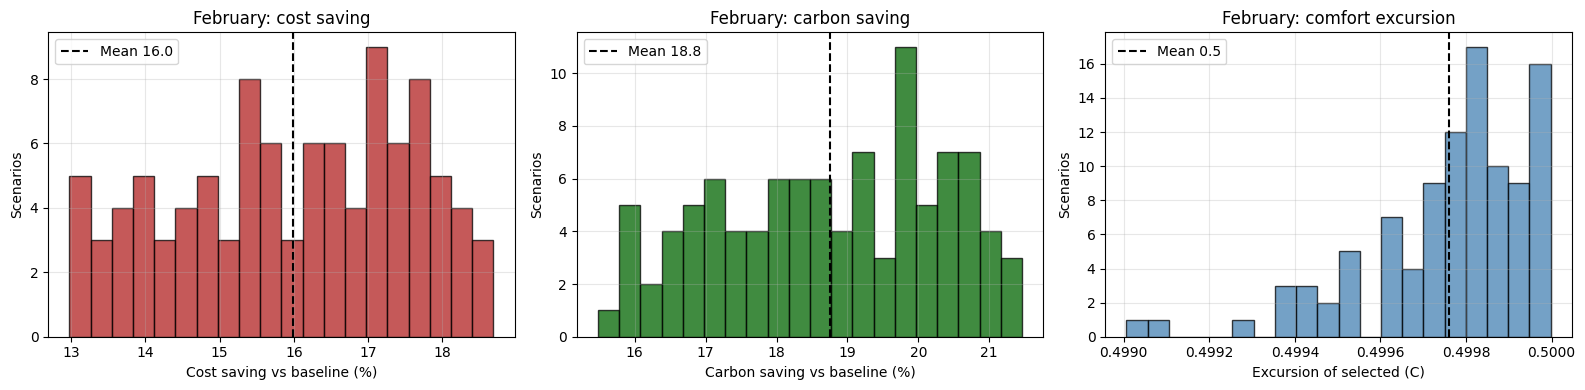

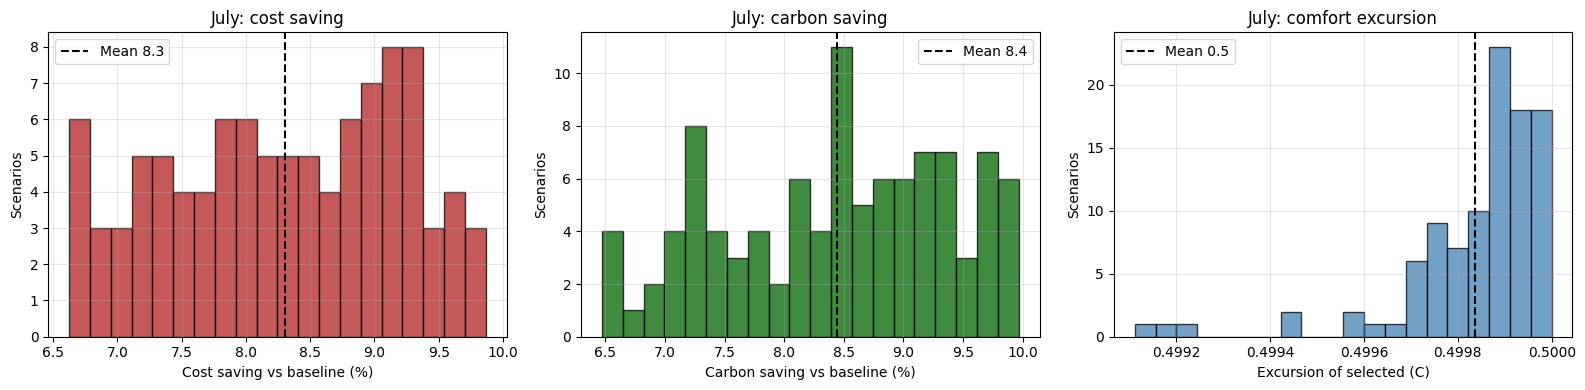

In [5]:
def panel(ax, data, color, title, xlabel):
    if len(data) == 0:
        ax.set_title(title + " (no feasible scenarios)")
        return
    ax.hist(data, bins=20, color=color, alpha=0.75, edgecolor="black")
    ax.axvline(np.mean(data), color="black", linestyle="--",
               label=f"Mean {np.mean(data):.1f}")
    ax.set_title(title); ax.set_xlabel(xlabel)
    ax.set_ylabel("Scenarios"); ax.legend(); ax.grid(alpha=0.3)

for label, rdf in [("February", res_feb), ("July", res_jul)]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    panel(axes[0], rdf["cost_saving_pct"], "firebrick",
          f"{label}: cost saving", "Cost saving vs baseline (%)")
    panel(axes[1], rdf["carbon_saving_pct"], "darkgreen",
          f"{label}: carbon saving", "Carbon saving vs baseline (%)")
    panel(axes[2], rdf["comfort_excursion_c"], "steelblue",
          f"{label}: comfort excursion", "Excursion of selected (C)")
    plt.tight_layout()
    fname = f"sensitivity_{label.lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print("Saved", fname)

In [ ]:
# summary
def summarise(name, rdf):
    if len(rdf) == 0:
        print(f"{name}: no feasible scenarios"); return
    print(f"{name}:  cost {rdf.cost_saving_pct.mean():5.1f}% mean | "
          f"carbon {rdf.carbon_saving_pct.mean():5.1f}% mean | "
          f"feasible {len(rdf)}/{N_SCENARIOS}")
print("=== Two-season sensitivity summary ===")
summarise("February", res_feb)
summarise("July    ", res_jul)

=== Two-season sensitivity summary ===
February:  cost  16.0% mean | carbon  18.8% mean | feasible 100/100
July    :  cost   8.3% mean | carbon   8.4% mean | feasible 100/100
